In [24]:
import importlib
import aaro_draft
import pandas as pd
import matplotlib.pyplot as plt
import Conor
from IPython.display import Image, display
from joblib import Parallel, delayed

importlib.reload(aaro_draft)
importlib.reload(Conor)

<module 'Conor' from '/workspaces/Research-Skills-for-Financial-Mathematics/Conor.py'>

In [25]:
import aaro_draft as ad
import Conor as c

In [26]:
cfg = c.ExpConfig(
    alpha=0.5,
    label="alpha=0.5"
)
results = c.run_experiment([cfg], n_jobs=-1)



--- Running: alpha=0.5 ---
    Done. Final mean VPI: -38.507


In [27]:
results["alpha=0.5"]["vpi"][:10]

array([-154.08755912, -225.46534033, -154.37506579, -134.3632921 ,
       -143.67085166, -153.0676052 ,  -85.34538083,  -85.61672906,
       -106.23092755,  -78.15115882])

### Why very large values of $\alpha$ (e.g., 100 or 500) do not work well

In the algorithm, the exploration bonus in the UCB update is

$$
\text{UCB} = \frac{\text{scaling}}{n^\alpha} + \text{scaling}\cdot \text{radius},
$$

where $n$ is the number of visits to the active node.

When $\alpha$ is extremely large (e.g., 100 or 500), the term $n^{-\alpha}$ decays **extremely quickly**.

For example:

- $1 / 2^{100} \approx 7.9 \times 10^{-31}$
- $1 / 3^{100} \approx 5.2 \times 10^{-48}$

After only one or two visits, the exploration bonus from the $n^{-\alpha}$ term becomes essentially **zero**.

As a result:

- The algorithm stops encouraging exploration very early.
- The Q-value updates become almost purely greedy.
- The agent may commit prematurely to suboptimal regions of the state–action space.
- The adaptive partitioning receives poor information, which can degrade learning performance.

Although the radius term still provides some spatial optimism, the rapid collapse of $n^{-\alpha}$ makes the algorithm behave much less like a UCB-style method.

For this reason, extremely large values such as $\alpha = 100$ or $\alpha = 500$ are not very informative in practice. More meaningful comparisons usually occur for values such as

$$
\alpha \in [0.01, 1],
$$

where the exploration bonus decays at a reasonable rate.

In [29]:
print(results[label].keys())

dict_keys(['vpi', 'arms'])



--- Running: alpha=0.01 ---
    Done. Final mean VPI: -37.644

--- Running: alpha=0.05 ---
    Done. Final mean VPI: -36.387

--- Running: alpha=0.1 ---
    Done. Final mean VPI: -39.513

--- Running: alpha=0.5 ---
    Done. Final mean VPI: -38.535

--- Running: alpha=1 ---
    Done. Final mean VPI: -38.137

--- Running: alpha=5 ---
    Done. Final mean VPI: -33.160

--- Running: alpha=10 ---
    Done. Final mean VPI: -33.162

--- Running: alpha=50 ---
    Done. Final mean VPI: -34.244


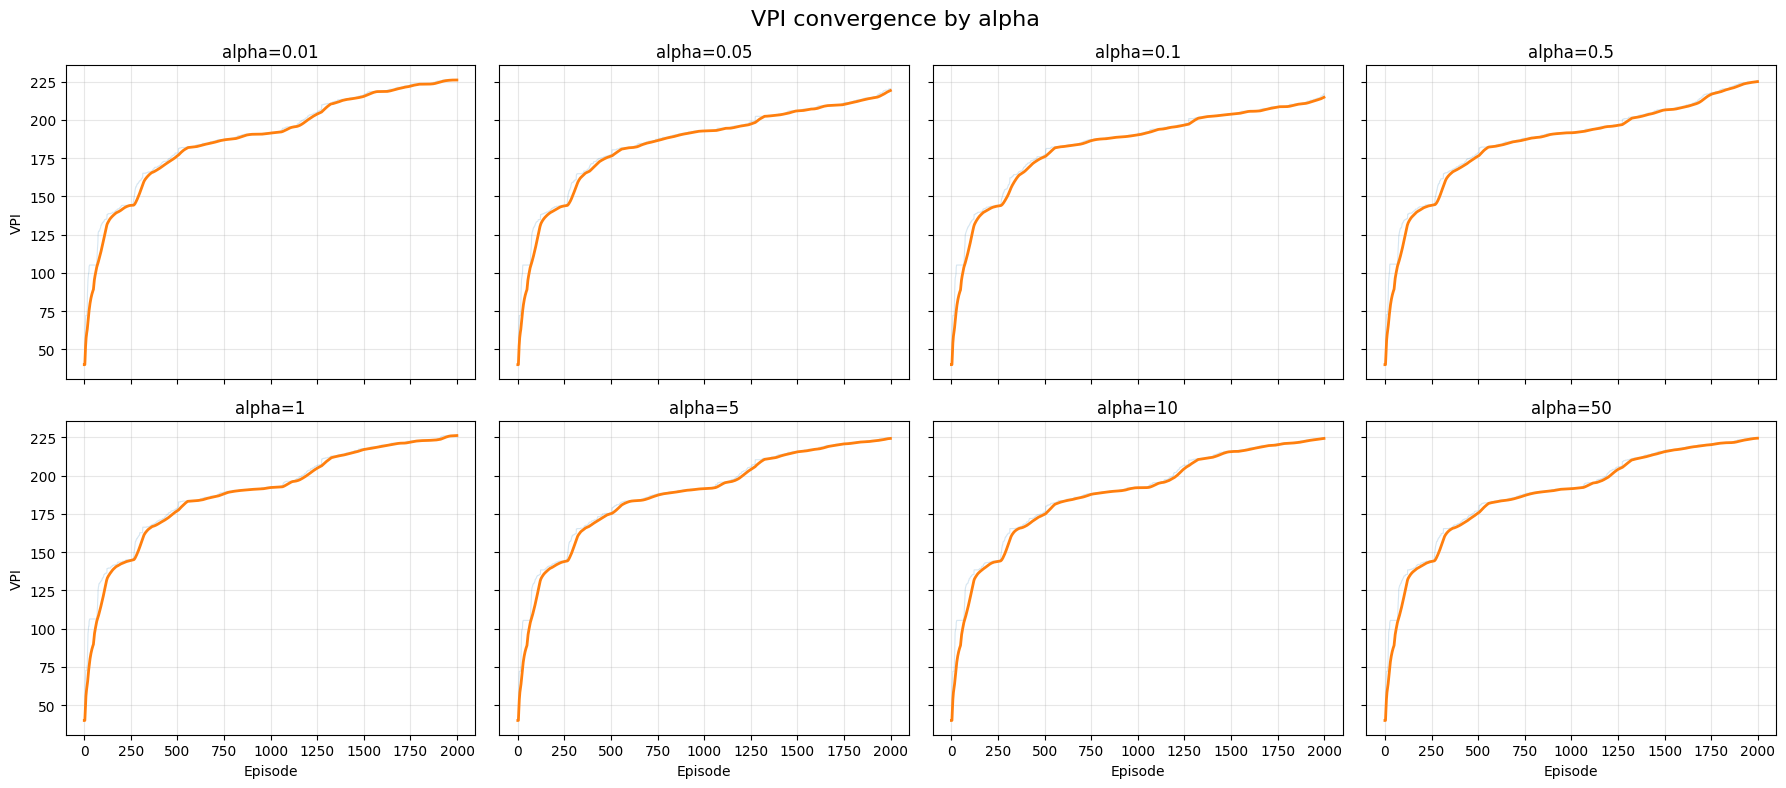

In [30]:
import numpy as np
import matplotlib.pyplot as plt
#alphas = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500]


alphas = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]

configs = [
    c.ExpConfig(alpha=a, label=f"alpha={a}")
    for a in alphas
]

results = c.run_experiment(configs, n_jobs=-1)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.ravel()

smooth_window = 50

for ax, a in zip(axes, alphas):
    label = f"alpha={a}"
    arms = np.asarray(results[label]["arms"], dtype=float)
    episodes = np.arange(len(arms))

    cumsum = np.cumsum(np.insert(arms, 0, 0.0))
    smoothed = np.empty_like(arms)
    for i in range(len(arms)):
        start = max(0, i - smooth_window + 1)
        smoothed[i] = (cumsum[i + 1] - cumsum[start]) / (i - start + 1)

    ax.plot(episodes, arms, alpha=0.18, linewidth=0.8)
    ax.plot(episodes, smoothed, linewidth=2)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

for i, ax in enumerate(axes):
    if i >= 4:
        ax.set_xlabel("Episode")
    if i % 4 == 0:
        ax.set_ylabel("VPI")

fig.suptitle("VPI convergence by alpha", fontsize=16)
fig.tight_layout()
plt.show()

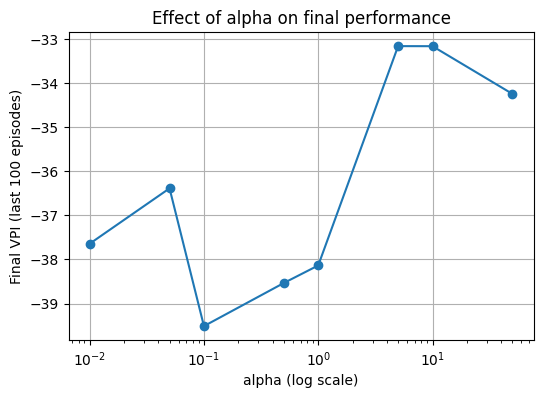

In [32]:


final_vpi = []

for a in alphas:
    label = f"alpha={a}"
    v = np.asarray(results[label]["vpi"], dtype=float)
    final_vpi.append(np.mean(v[-100:]))

plt.figure(figsize=(6,4))
plt.plot(alphas, final_vpi, marker='o')
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Final VPI (last 100 episodes)")
plt.title("Effect of alpha on final performance")
plt.grid(True)
plt.show()


--- Running: alpha=0.01 ---
    Done. Final mean VPI: -38.330

--- Running: alpha=0.05 ---
    Done. Final mean VPI: -36.689

--- Running: alpha=0.1 ---
    Done. Final mean VPI: -39.427

--- Running: alpha=0.5 ---
    Done. Final mean VPI: -37.969

--- Running: alpha=1 ---
    Done. Final mean VPI: -37.203

--- Running: alpha=5 ---
    Done. Final mean VPI: -32.234

--- Running: alpha=10 ---
    Done. Final mean VPI: -34.157

--- Running: alpha=50 ---
    Done. Final mean VPI: -31.052


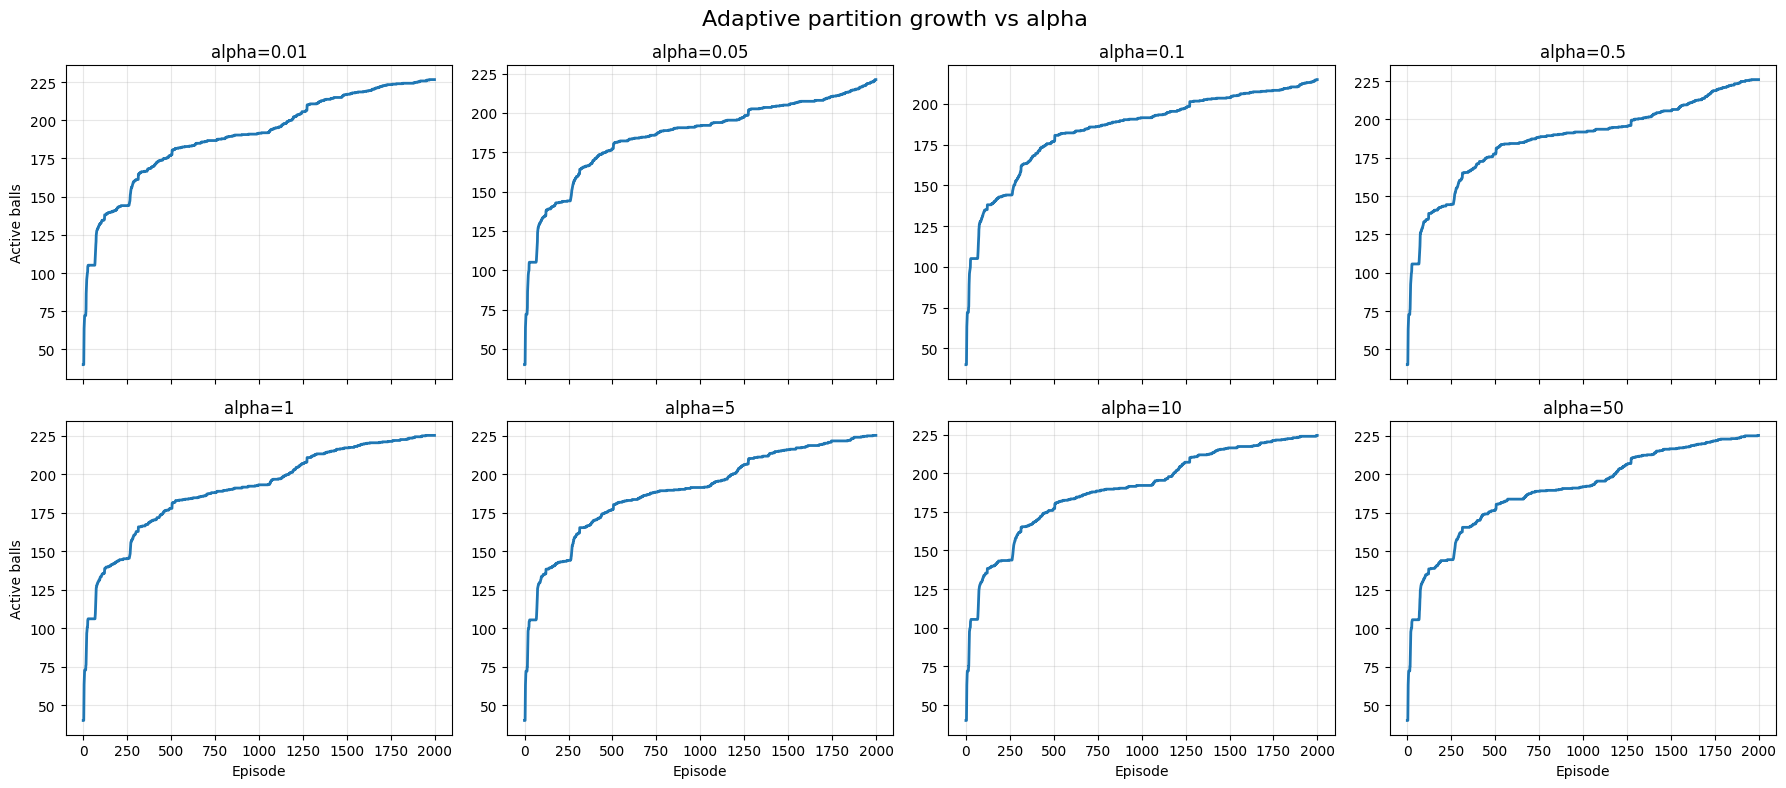

In [33]:
alphas = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]

configs = [
    c.ExpConfig(alpha=a, label=f"alpha={a}")
    for a in alphas
]

results = c.run_experiment(configs, n_jobs=-1)


fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)
axes = axes.ravel()

for ax, a in zip(axes, alphas):
    label = f"alpha={a}"
    arms = results[label]["arms"]

    ax.plot(arms, linewidth=2)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

for i, ax in enumerate(axes):
    if i >= 4:
        ax.set_xlabel("Episode")
    if i % 4 == 0:
        ax.set_ylabel("Active balls")

fig.suptitle("Adaptive partition growth vs alpha", fontsize=16)
fig.tight_layout()
plt.show()

The above plot explains how quick the partition grows. We seee rapid growth early on and then a plateua arond 200 ish. Overall the algorithim doesnt seem to be vey sensitive to alpha as there is little difference between alpha = 0.1 and alpha = 50

In [ ]:
n_simulations = 50 

print(f"Starting {n_simulations} parallel experiments...")

# Run the parallel experiment loop using the function from your imported module
# This triggers run_single_experiment_iteration(i) for i in range(0, 50)
list_of_results = Parallel(n_jobs=-1)(
    delayed(ae.run_single_experiment_iteration)(i) for i in range(n_simulations)
)

# Process the results into a mean estimate (VPI)
vpi_df = pd.DataFrame(list_of_results).T
vpi_estimate = vpi_df.mean(axis=1)

# Generate the plot
plt.figure(figsize=(10, 6))
plt.plot(range(len(vpi_estimate)), vpi_estimate, label='VPI (Average Reward)', color='blue')
plt.xlabel("Episode")
plt.ylabel("Value Performance Index")
plt.title("Agent Performance: VPI vs Episode (Portfolio Optimization)")
plt.legend()
plt.grid(True)
plt.show()

# final average reward achieved
print(f"Final Average Reward after {ad.nEps} episodes: {vpi_estimate.iloc[-1]:.4f}")

In [40]:

cfgs = [
    c.ExpConfig(alpha=0.5, starting_state=s0, rho=30.0, label=f"start={s0}|alpha=0.5")
    for s0 in [-20, -10, 0, 4, 10, 20]
]

res = c.run_experiment(cfgs, n_jobs=1)
print(res.keys())


--- Running: start=-20|alpha=0.5 ---
    Done. Final mean VPI: -2267.567

--- Running: start=-10|alpha=0.5 ---
    Done. Final mean VPI: -526.451

--- Running: start=0|alpha=0.5 ---
    Done. Final mean VPI: -177.216

--- Running: start=4|alpha=0.5 ---
    Done. Final mean VPI: -48.202

--- Running: start=10|alpha=0.5 ---
    Done. Final mean VPI: -0.802

--- Running: start=20|alpha=0.5 ---
    Done. Final mean VPI: -268.891
dict_keys(['start=-20|alpha=0.5', 'start=-10|alpha=0.5', 'start=0|alpha=0.5', 'start=4|alpha=0.5', 'start=10|alpha=0.5', 'start=20|alpha=0.5'])


In [35]:
test_config = [c.ExpConfig(alpha=0.5, starting_state=4, label="alpha=0.5")]
test_result = c.run_experiment(test_config, n_jobs=1)
print(test_result)


--- Running: alpha=0.5 ---
    Done. Final mean VPI: -38.977
{'alpha=0.5': {'vpi': array([-154.08755912, -225.46534033, -154.37506579, ...,  -40.58810678,
        -38.52864856,  -37.91931238], shape=(2000,)), 'arms': array([ 40.,  40.,  40., ..., 226., 226., 226.], shape=(2000,))}}


In [36]:
cfg = c.ExpConfig(alpha=0.5, starting_state=4, label="alpha=0.5")
print(cfg)
print(vars(cfg) if hasattr(cfg, "__dict__") else "no __dict__")

ExpConfig(state_dim=1, action_dim=1, epLen=10, nEps=2000, n_seeds=10, starting_state=4, domain_lo=-50.0, domain_hi=50.0, initial_q=1837.1, rho=10.0, rho_1=5.0, lip=1.0, split_threshold=2, scaling=5.0, alpha=0.5, theta_0=0.05, theta_x=-0.1, theta_a=0.01, sigma=0.1, delta=1.0, reward_step_fn=<function reward_6_1 at 0x72e3adb37f60>, label='alpha=0.5')
{'state_dim': 1, 'action_dim': 1, 'epLen': 10, 'nEps': 2000, 'n_seeds': 10, 'starting_state': 4, 'domain_lo': -50.0, 'domain_hi': 50.0, 'initial_q': 1837.1, 'rho': 10.0, 'rho_1': 5.0, 'lip': 1.0, 'split_threshold': 2, 'scaling': 5.0, 'alpha': 0.5, 'theta_0': 0.05, 'theta_x': -0.1, 'theta_a': 0.01, 'sigma': 0.1, 'delta': 1.0, 'reward_step_fn': <function reward_6_1 at 0x72e3adb37f60>, 'label': 'alpha=0.5', '_sigma_sqrt_delta': 0.1}
